# External Data Fetching — Tore, Kalix Kommune

This notebook downloads and processes all external datasets needed for the simulation.

## Location
| Parameter | Value |
|---|---|
| Location | Tore, Kalix kommun, Luleå |
| Latitude | 65.9172°N |
| Longitude | 22.6501°E |
| Bidding zone | **SE1** (northernmost Sweden) |
| Simulation year | **2025** (non-leap, full year under current marginal FCR-D pricing) |

## What this notebook does

| Step | Dataset | Source | Method |
|---|---|---|---|
| §1 | Weather / Solar irradiance (TMY) | PVGIS EU API | ✅ Fully automatic |
| §2 | Spot electricity prices (SE1, 2025) | elprisetjustnu.se API | ✅ Fully automatic |
| §3 | FCR-D clearing prices (2025) | SVK Mimer CSV in `data/raw/` | ✅ Fully automatic |
| §4 | Your own consumption data | Hardcoded monthly totals | ✅ Fully automatic |
| §5 | Validate all parquet files | — | ✅ Automatic check |

In [1]:
# ── Shared config — edit here only ──────────────────────────────────────────
LAT          = 65.9172     # Tore, Kalix
LON          = 22.6501
BIDDING_ZONE = "SE1"       # SE1 = Luleå / northernmost Sweden
SIM_YEAR     = 2025        # 2025 = full year under current marginal FCR-D pricing
# ────────────────────────────────────────────────────────────────────────────

import pathlib, warnings, json, io, time, datetime, calendar
import numpy as np
import pandas as pd

RAW_DIR       = pathlib.Path("../data/raw")
PROCESSED_DIR = pathlib.Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

YEAR = str(SIM_YEAR)   # used in all filenames

print(f"Location : {LAT}°N, {LON}°E  (Tore, Kalix)")
print(f"Zone     : {BIDDING_ZONE}")
print(f"Year     : {SIM_YEAR}")
print(f"Raw dir  : {RAW_DIR.resolve()}")
print(f"Out dir  : {PROCESSED_DIR.resolve()}")

Location : 65.9172°N, 22.6501°E  (Tore, Kalix)
Zone     : SE1
Year     : 2025
Raw dir  : C:\Users\Serge\source\solar\data\raw
Out dir  : C:\Users\Serge\source\solar\data\processed


---
## §1 — Solar Irradiance / TMY Weather (PVGIS — fully automatic)

Fetches a **Typical Meteorological Year** from the EU Joint Research Centre's PVGIS API.
No login, no key needed. The TMY is location-specific (not calendar-year specific) —
PVGIS splices the best representative months from 2005–2023 regardless of `SIM_YEAR`.  
We re-label all timestamps to `SIM_YEAR` for simulation alignment.

In [2]:
import urllib.request

PVGIS_URL = (
    f"https://re.jrc.ec.europa.eu/api/v5_3/tmy"
    f"?lat={LAT}&lon={LON}&outputformat=json"
)

print(f"Fetching PVGIS TMY…\n  {PVGIS_URL}")

with urllib.request.urlopen(PVGIS_URL, timeout=60) as resp:
    pvgis_raw = json.loads(resp.read())

meta = pvgis_raw["inputs"]
print(f"\nPVGIS metadata:")
print(f"  Elevation  : {meta['location']['elevation']:.0f} m")
print(f"  Database   : {meta['meteo_data']['radiation_db']}")
print(f"  Years used : {meta['meteo_data']['year_min']}–{meta['meteo_data']['year_max']}")
months_used = [(m['month'], m['year']) for m in pvgis_raw['outputs']['months_selected']]
print(f"  TMY months : {months_used}")

weather_df = pd.DataFrame(pvgis_raw["outputs"]["tmy_hourly"])
print(f"\nRows fetched: {len(weather_df)}  (expected 8760)")

Fetching PVGIS TMY…
  https://re.jrc.ec.europa.eu/api/v5_3/tmy?lat=65.9172&lon=22.6501&outputformat=json



PVGIS metadata:
  Elevation  : 30 m
  Database   : PVGIS-ERA5
  Years used : 2005–2023
  TMY months : [(1, 2010), (2, 2016), (3, 2017), (4, 2018), (5, 2010), (6, 2016), (7, 2008), (8, 2023), (9, 2006), (10, 2018), (11, 2009), (12, 2020)]

Rows fetched: 8760  (expected 8760)


In [3]:
def pvgis_ts_to_datetime(s, target_year):
    """Convert PVGIS '20100115:1300' → Timestamp in target_year (UTC)."""
    mmdd = s[4:8]
    hh   = s[9:11]
    mm   = s[11:13]
    return pd.Timestamp(f"{target_year}-{mmdd[:2]}-{mmdd[2:]} {hh}:{mm}:00", tz="UTC")

weather_df["timestamp"] = weather_df["time(UTC)"].apply(
    lambda s: pvgis_ts_to_datetime(s, SIM_YEAR)
)
weather_df = weather_df.set_index("timestamp").drop(columns=["time(UTC)"])
weather_df = weather_df[~((weather_df.index.month == 2) & (weather_df.index.day == 29))]
weather_df = weather_df.iloc[:8760]

print(f"Final rows : {len(weather_df)}  (must be 8760)")
print(f"Index range: {weather_df.index[0]} → {weather_df.index[-1]}")
print(weather_df.describe().T[["mean", "min", "max"]].round(2))

Final rows : 8760  (must be 8760)
Index range: 2025-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
            mean       min        max
T2m         3.80    -23.14      25.37
RH         81.70     27.30     100.00
G(h)      103.68      0.00     733.90
Gb(n)     146.36      0.00     930.50
Gd(h)      42.45      0.00     329.10
IR(h)     289.18    158.70     413.00
WS10m       2.27      0.00       8.14
WD10m     171.57      0.00     360.00
SP     100599.44  97140.00  104110.00


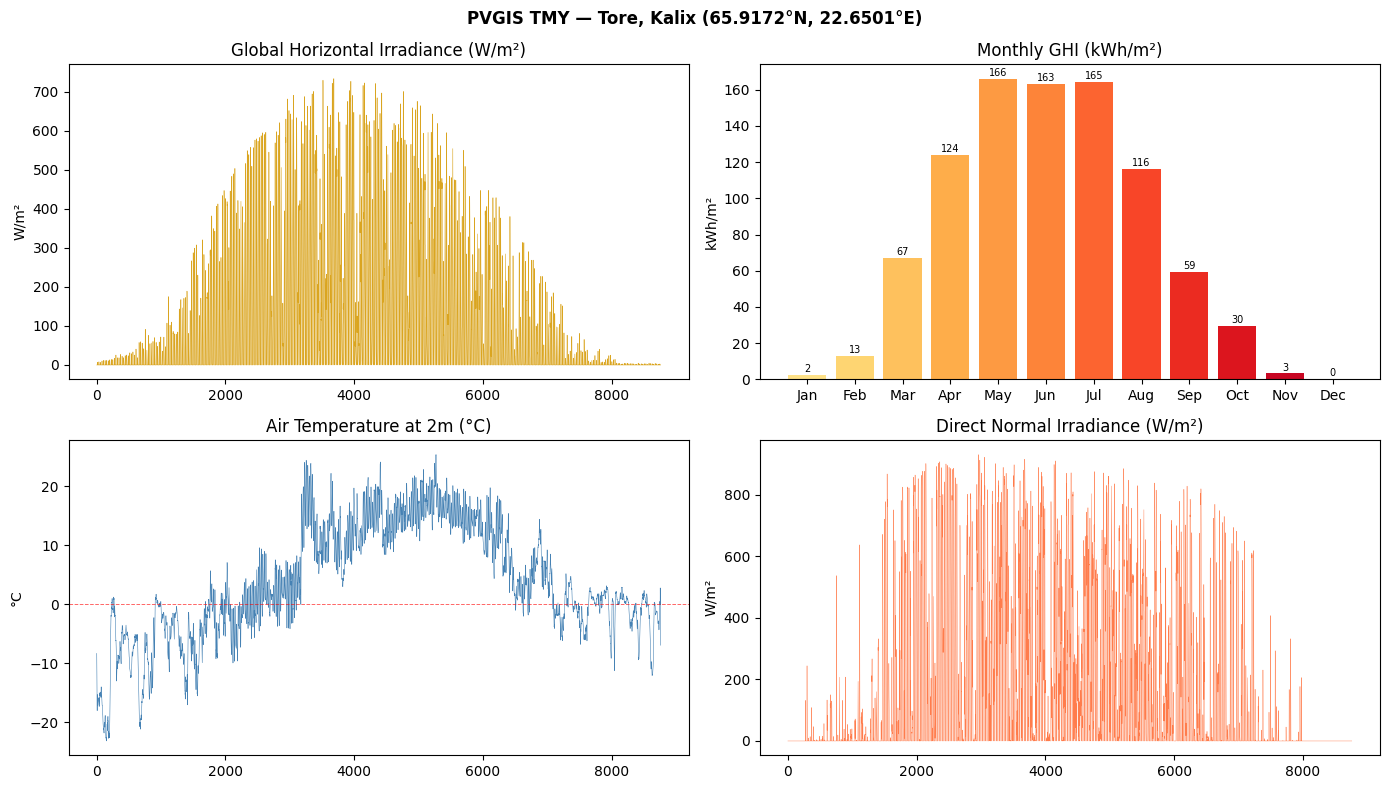

Annual GHI: 908 kWh/m²  |  Mean temp: 3.8°C  |  Min: -23.1°C


In [4]:
import matplotlib.pyplot as plt

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_slices = [(0,744),(744,1416),(1416,2160),(2160,2880),(2880,3624),
                (3624,4344),(4344,5088),(5088,5832),(5832,6552),
                (6552,7296),(7296,8016),(8016,8760)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'PVGIS TMY — Tore, Kalix ({LAT}°N, {LON}°E)', fontsize=12, fontweight='bold')

axes[0,0].plot(weather_df['G(h)'].values, linewidth=0.4, color='goldenrod')
axes[0,0].set_title('Global Horizontal Irradiance (W/m²)'); axes[0,0].set_ylabel('W/m²')

monthly_ghi = [weather_df['G(h)'].iloc[s:e].sum()/1000 for s,e in month_slices]
bars = axes[0,1].bar(month_labels, monthly_ghi, color=plt.cm.YlOrRd(np.linspace(0.2, 0.9, 12)))
axes[0,1].set_title('Monthly GHI (kWh/m²)'); axes[0,1].set_ylabel('kWh/m²')
for b,v in zip(bars,monthly_ghi): axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

axes[1,0].plot(weather_df['T2m'].values, linewidth=0.4, color='steelblue')
axes[1,0].axhline(0, color='red', linewidth=0.7, linestyle='--', alpha=0.6)
axes[1,0].set_title('Air Temperature at 2m (°C)'); axes[1,0].set_ylabel('°C')

axes[1,1].plot(weather_df['Gb(n)'].values, linewidth=0.3, color='orangered', alpha=0.7)
axes[1,1].set_title('Direct Normal Irradiance (W/m²)'); axes[1,1].set_ylabel('W/m²')

plt.tight_layout()
plt.savefig(RAW_DIR / 'weather_tmy_tore_preview.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Annual GHI: {weather_df['G(h)'].sum()/1000:.0f} kWh/m²  |  Mean temp: {weather_df['T2m'].mean():.1f}°C  |  Min: {weather_df['T2m'].min():.1f}°C")

In [5]:
from solar.data.loader import save_to_parquet

weather_df.to_csv(RAW_DIR / "weather_tmy_tore.csv")
print(f"Saved raw CSV → {RAW_DIR / 'weather_tmy_tore.csv'}")

weather_cols = {
    "G(h)"  : f"ghi_{YEAR}.parquet",
    "Gb(n)" : f"dni_{YEAR}.parquet",
    "Gd(h)" : f"dhi_{YEAR}.parquet",
    "T2m"   : f"temperature_{YEAR}.parquet",
    "WS10m" : f"wind_speed_{YEAR}.parquet",
}
for col, fname in weather_cols.items():
    df_col = pd.DataFrame({col: weather_df[col].values})
    save_to_parquet(df_col, PROCESSED_DIR / fname)
    print(f"  Saved {fname:40s} shape={df_col.shape}")
print("\n✅ PVGIS weather data complete")

Saved raw CSV → ..\data\raw\weather_tmy_tore.csv
  Saved ghi_2025.parquet                         shape=(8760, 1)
  Saved dni_2025.parquet                         shape=(8760, 1)
  Saved dhi_2025.parquet                         shape=(8760, 1)
  Saved temperature_2025.parquet                 shape=(8760, 1)
  Saved wind_speed_2025.parquet                  shape=(8760, 1)

✅ PVGIS weather data complete


---
## §2 — Spot Electricity Prices SE1, 2025 (elprisetjustnu.se — fully automatic)

Uses the free **elprisetjustnu.se** API — no registration, no API key.  
Prices are already in **SEK/kWh**. 365 daily requests → 8760 hourly records.

Also derives the **hourly EUR→SEK exchange rate** (SEK_per_kWh ÷ EUR_per_kWh) used in §3 to convert FCR-D prices.

In [6]:
SPOT_OUT = PROCESSED_DIR / f"spot_prices_se1_{YEAR}.parquet"

start = datetime.date(SIM_YEAR, 1, 1)
days  = [start + datetime.timedelta(days=i) for i in range(365)]
spot_records = []
failed_days  = []

headers = {"User-Agent": "Mozilla/5.0 (simulation-notebook)", "Accept": "application/json"}

print(f"Fetching SE1 spot prices for {SIM_YEAR} from elprisetjustnu.se …  (~40 s)\n")
for i, day in enumerate(days):
    url = (f"https://www.elprisetjustnu.se/api/v1/prices/"
           f"{day.year}/{day.month:02d}-{day.day:02d}_{BIDDING_ZONE}.json")
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=15) as resp:
            daily = json.loads(resp.read())
        if isinstance(daily, list) and daily:
            spot_records.extend(daily)
        else:
            failed_days.append(day)
    except Exception as e:
        failed_days.append(day)
        print(f"  ⚠️  {day}: {type(e).__name__}")
    if i % 30 == 29:
        print(f"  … {i+1}/365  (records: {len(spot_records)})")
    time.sleep(0.1)

print(f"\nRecords fetched: {len(spot_records)}  |  Failed days: {len(failed_days)}")

Fetching SE1 spot prices for 2025 from elprisetjustnu.se …  (~40 s)



  … 30/365  (records: 720)


  … 60/365  (records: 1440)


  … 90/365  (records: 2159)


  … 120/365  (records: 2879)


...

  … 270/365  (records: 6479)


  … 300/365  (records: 9147)


  … 330/365  (records: 12027)


  … 360/365  (records: 14907)



Records fetched: 15387  |  Failed days: 0


Rows       : 15387  (expected 8760)
Spot prices: -1.0430 – 3.0107 SEK/kWh  (mean 0.2237)
EUR→SEK    : 10.67 – 11.55  (mean 11.02)



✅ Saved spot_prices_se1_2025.parquet  shape=(8760, 1)
EUR→SEK array: 8760 values, mean=11.08


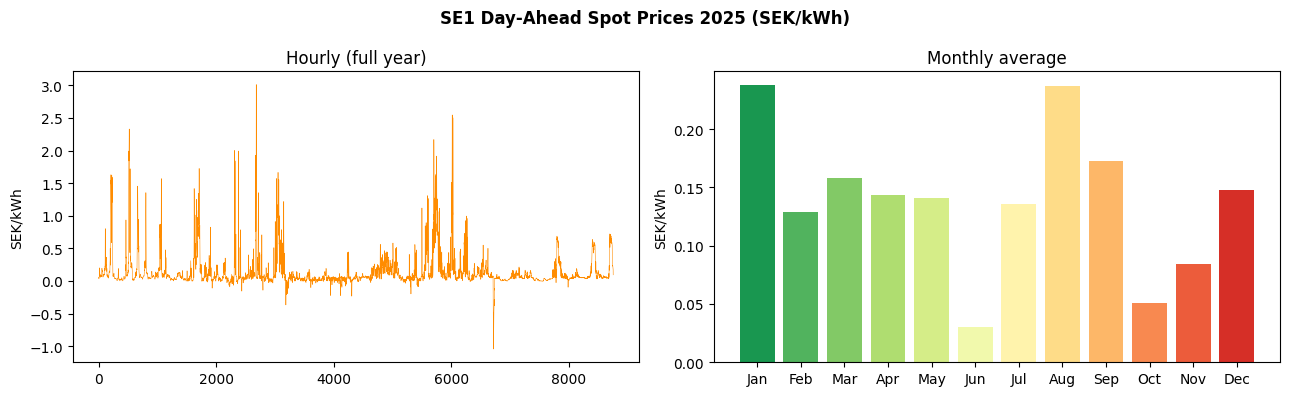

In [7]:
spot_df_raw = pd.DataFrame([r for r in spot_records if isinstance(r, dict) and 'SEK_per_kWh' in r])
spot_df_raw["time_start"] = pd.to_datetime(spot_df_raw["time_start"], utc=True)
spot_df_raw = spot_df_raw.sort_values("time_start").reset_index(drop=True)

spot_df_raw["spot_prices"] = pd.to_numeric(spot_df_raw["SEK_per_kWh"], errors='coerce')
spot_df_raw["eur_per_kwh"] = pd.to_numeric(spot_df_raw["EUR_per_kWh"], errors='coerce')

# Derive hourly EUR→SEK rate (SEK/kWh ÷ EUR/kWh); forward-fill zeros/NaN
eur_nonzero = spot_df_raw["eur_per_kwh"].abs() > 1e-9
spot_df_raw["eur_to_sek"] = np.where(
    eur_nonzero, spot_df_raw["spot_prices"] / spot_df_raw["eur_per_kwh"], np.nan
)
spot_df_raw["eur_to_sek"] = spot_df_raw["eur_to_sek"].ffill().bfill()
spot_df_raw = spot_df_raw.dropna(subset=["spot_prices"])

print(f"Rows       : {len(spot_df_raw)}  (expected 8760)")
print(f"Spot prices: {spot_df_raw['spot_prices'].min():.4f} – {spot_df_raw['spot_prices'].max():.4f} SEK/kWh  (mean {spot_df_raw['spot_prices'].mean():.4f})")
print(f"EUR→SEK    : {spot_df_raw['eur_to_sek'].min():.2f} – {spot_df_raw['eur_to_sek'].max():.2f}  (mean {spot_df_raw['eur_to_sek'].mean():.2f})")

# Save raw CSV + processed parquet
spot_df_raw[["time_start","SEK_per_kWh","EUR_per_kWh","eur_to_sek"]].to_csv(
    RAW_DIR / f"spot_prices_se1_{YEAR}.csv", index=False)
spot_df = pd.DataFrame({"spot_prices": spot_df_raw["spot_prices"].values[:8760]})
save_to_parquet(spot_df, SPOT_OUT)
print(f"\n✅ Saved {SPOT_OUT.name}  shape={spot_df.shape}")

# Expose exchange rate array for §3
EUR_TO_SEK_ARRAY = spot_df_raw["eur_to_sek"].values[:8760]
print(f"EUR→SEK array: {len(EUR_TO_SEK_ARRAY)} values, mean={EUR_TO_SEK_ARRAY.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'SE1 Day-Ahead Spot Prices {SIM_YEAR} (SEK/kWh)', fontsize=12, fontweight='bold')
axes[0].plot(spot_df['spot_prices'].values, linewidth=0.4, color='darkorange')
axes[0].set_title('Hourly (full year)'); axes[0].set_ylabel('SEK/kWh')
monthly_avg = [spot_df['spot_prices'].iloc[s:e].mean() for s,e in month_slices]
axes[1].bar(month_labels, monthly_avg, color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 12)))
axes[1].set_title('Monthly average'); axes[1].set_ylabel('SEK/kWh')
plt.tight_layout(); plt.show()

---
## §3 — FCR-D Clearing Prices 2025 (SVK Mimer CSV — fully automatic)

Reads pre-downloaded SVK export files from `data/raw/`:
- `fcr_d_up_prices_2025.csv`
- `fcr_d_down_prices_2025.csv`

### File format notes
| Property | Value |
|---|---|
| Encoding | UTF-8 with BOM → `utf-8-sig` |
| Decimal separator | Comma (European) → `decimal=','` |
| Units | **EUR/MW/h** → converted to **SEK/MW/h** |
| Granularity | Hourly (8760 data rows + 1 'Summa' footer) |
| Both files | Contain the same set of columns (full SVK export with FCR-N, FCR-D up, FCR-D down) |

The EUR→SEK conversion uses the **hourly rate derived from real spot data** in §2 (not a fixed annual estimate).

In [8]:
def load_fcr_svk(fpath: pathlib.Path, price_col: str, out_col: str,
                  eur_to_sek_arr: np.ndarray) -> pd.DataFrame:
    """
    Load an SVK FCR CSV (UTF-8-BOM, comma decimals, hourly).
    Drops the trailing 'Summa' footer row.
    Converts EUR/MW/h → SEK/MW/h using the hourly exchange rate array.
    Returns a 1-column DataFrame with exactly 8760 rows.
    """
    # Try semicolon first (SVK sometimes uses this), fall back to comma
    df = pd.read_csv(fpath, encoding="utf-8-sig", sep=";", decimal=",")
    if len(df.columns) <= 2:
        df = pd.read_csv(fpath, encoding="utf-8-sig", sep=",", decimal=",")
    df.columns = [c.strip() for c in df.columns]

    # Drop summary / non-timestamp rows (e.g. 'Summa' at end)
    df = df[df["Datum"].str.match(r"\d{4}-\d{2}-\d{2}", na=False)].reset_index(drop=True)

    df["ts"] = pd.to_datetime(df["Datum"])
    df = df[df["ts"].dt.year == SIM_YEAR].sort_values("ts").reset_index(drop=True)

    prices_eur = df[price_col].values.astype(float)
    rate       = eur_to_sek_arr[:len(prices_eur)]
    prices_sek = prices_eur * rate

    print(f"  {fpath.name}")
    print(f"    Rows        : {len(df)}  (expected 8760)")
    print(f"    EUR/MW range: {prices_eur.min():.2f} – {prices_eur.max():.2f}  mean={prices_eur.mean():.2f}")
    print(f"    SEK/MW range: {prices_sek.min():.1f} – {prices_sek.max():.1f}  mean={prices_sek.mean():.1f}")

    return pd.DataFrame({out_col: prices_sek[:8760]})


FCR_UP_RAW   = RAW_DIR / f"fcr_d_up_prices_{YEAR}.csv"
FCR_DOWN_RAW = RAW_DIR / f"fcr_d_down_prices_{YEAR}.csv"
FCR_UP_OUT   = PROCESSED_DIR / f"fcr_d_up_{YEAR}.parquet"
FCR_DOWN_OUT = PROCESSED_DIR / f"fcr_d_down_{YEAR}.parquet"

UP_COL   = "FCR-D upp Pris (EUR/MW)"
DOWN_COL = "FCR-D ned Pris (EUR/MW)"

print("=== Processing FCR-D files ===")
if FCR_UP_RAW.exists() and FCR_DOWN_RAW.exists():
    fcr_up_df   = load_fcr_svk(FCR_UP_RAW,   UP_COL,   "fcr_d_up_prices",   EUR_TO_SEK_ARRAY)
    fcr_down_df = load_fcr_svk(FCR_DOWN_RAW, DOWN_COL, "fcr_d_down_prices", EUR_TO_SEK_ARRAY)

    save_to_parquet(fcr_up_df,   FCR_UP_OUT)
    save_to_parquet(fcr_down_df, FCR_DOWN_OUT)
    print(f"\n✅ Saved {FCR_UP_OUT.name}    shape={fcr_up_df.shape}")
    print(f"✅ Saved {FCR_DOWN_OUT.name}  shape={fcr_down_df.shape}")
else:
    missing = [f for f in [FCR_UP_RAW, FCR_DOWN_RAW] if not f.exists()]
    print(f"⚠️  Missing files: {[str(m) for m in missing]}")

=== Processing FCR-D files ===
  fcr_d_up_prices_2025.csv
    Rows        : 8760  (expected 8760)
    EUR/MW range: 0.76 – 126.14  mean=6.07
    SEK/MW range: 8.3 – 1377.9  mean=67.2
  fcr_d_down_prices_2025.csv
    Rows        : 8760  (expected 8760)
    EUR/MW range: 0.85 – 773.71  mean=5.92
    SEK/MW range: 9.3 – 8542.2  mean=65.4

✅ Saved fcr_d_up_2025.parquet    shape=(8760, 1)
✅ Saved fcr_d_down_2025.parquet  shape=(8760, 1)


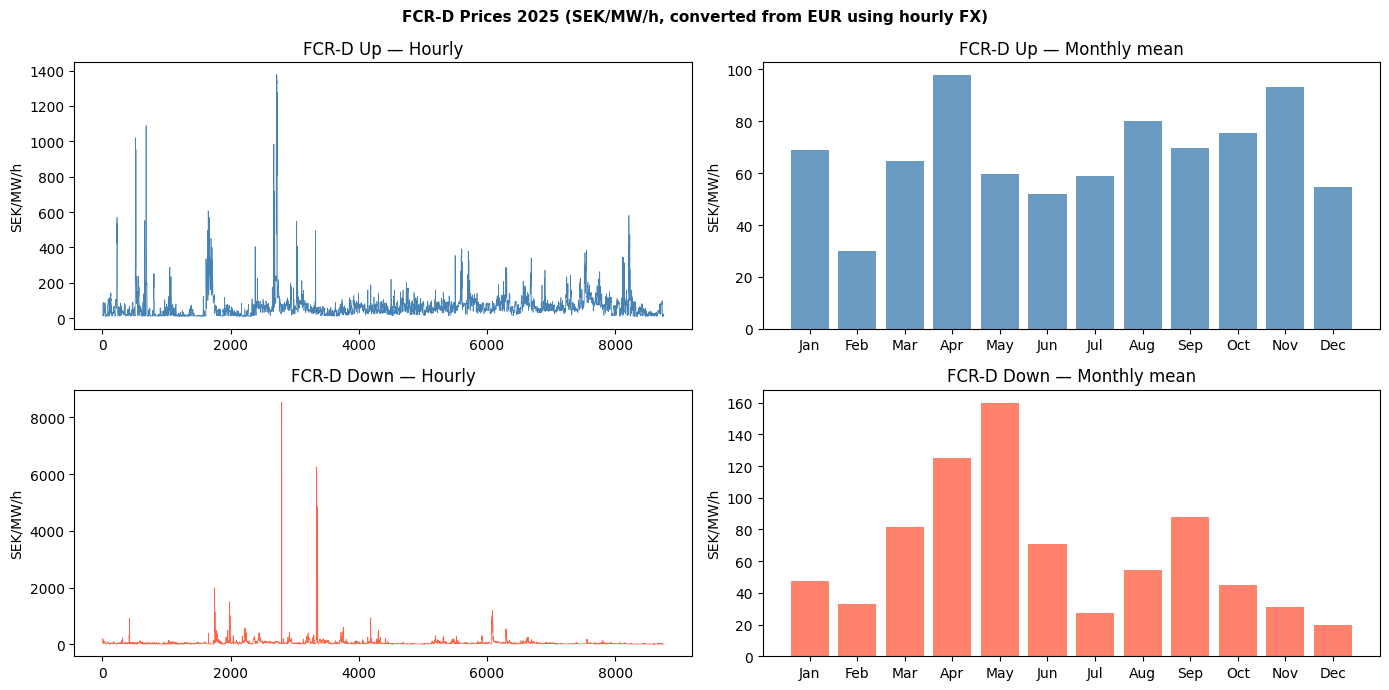

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(f'FCR-D Prices {SIM_YEAR} (SEK/MW/h, converted from EUR using hourly FX)', fontsize=11, fontweight='bold')

axes[0,0].plot(fcr_up_df['fcr_d_up_prices'].values, linewidth=0.5, color='steelblue')
axes[0,0].set_title('FCR-D Up — Hourly'); axes[0,0].set_ylabel('SEK/MW/h')

monthly_up = [fcr_up_df['fcr_d_up_prices'].iloc[s:e].mean() for s,e in month_slices]
axes[0,1].bar(month_labels, monthly_up, color='steelblue', alpha=0.8)
axes[0,1].set_title('FCR-D Up — Monthly mean'); axes[0,1].set_ylabel('SEK/MW/h')

axes[1,0].plot(fcr_down_df['fcr_d_down_prices'].values, linewidth=0.5, color='tomato')
axes[1,0].set_title('FCR-D Down — Hourly'); axes[1,0].set_ylabel('SEK/MW/h')

monthly_down = [fcr_down_df['fcr_d_down_prices'].iloc[s:e].mean() for s,e in month_slices]
axes[1,1].bar(month_labels, monthly_down, color='tomato', alpha=0.8)
axes[1,1].set_title('FCR-D Down — Monthly mean'); axes[1,1].set_ylabel('SEK/MW/h')

plt.tight_layout(); plt.show()

---
## §4 — Consumption Profile (monthly totals → hourly flat)

Monthly totals are distributed **uniformly** across the hours in each month.
This gives a step-function profile — a reasonable baseline until hourly meter data is available.

Annual total : 11,689 kWh
Hourly array : 8760 values  |  sum check: 11689.0 kWh
Peak rate    : 2.769 kWh/h  |  Min: 0.411 kWh/h

Saved monthly CSV: ..\data\raw\consumption_monthly_2025.csv
Saved parquet  : load_profile_2025.parquet  shape=(8760, 1)


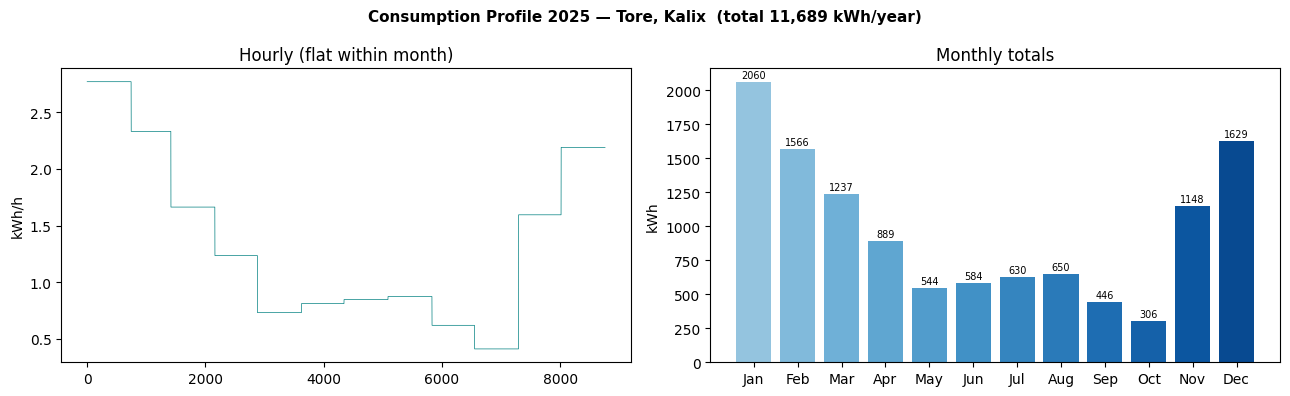


✅ Consumption profile complete


In [10]:
# ── Monthly totals (kWh) — update here as needed ──────────────────────────────
MONTHLY_KWH = {
     1: 2060,   # Jan
     2: 1566,   # Feb
     3: 1237,   # Mar
     4:  889,   # Apr
     5:  544,   # Maj
     6:  584,   # Jun
     7:  630,   # Jul
     8:  650,   # Aug
     9:  446,   # Sep
    10:  306,   # Okt
    11: 1148,   # Nov
    12: 1629,   # Dec
}
# ─────────────────────────────────────────────────────────────────────────────

annual_kwh = sum(MONTHLY_KWH.values())

# Expand to 8760-hour flat profile
hourly = []
for month, total in MONTHLY_KWH.items():
    _, n_days = calendar.monthrange(SIM_YEAR, month)
    n_hours = n_days * 24
    hourly.extend([total / n_hours] * n_hours)

consumption_arr = np.array(hourly[:8760])

print(f"Annual total : {annual_kwh:,} kWh")
print(f"Hourly array : {len(consumption_arr)} values  |  sum check: {consumption_arr.sum():.1f} kWh")
print(f"Peak rate    : {consumption_arr.max():.3f} kWh/h  |  Min: {consumption_arr.min():.3f} kWh/h")

# Save raw monthly CSV
monthly_df = pd.DataFrame({
    "month": list(MONTHLY_KWH.keys()),
    "month_name": [pd.Timestamp(SIM_YEAR, m, 1).strftime('%B') for m in MONTHLY_KWH],
    "kwh": list(MONTHLY_KWH.values()),
})
monthly_df.to_csv(RAW_DIR / f"consumption_monthly_{YEAR}.csv", index=False)
print(f"\nSaved monthly CSV: {RAW_DIR / f'consumption_monthly_{YEAR}.csv'}")

# Save processed parquet
LOAD_OUT = PROCESSED_DIR / f"load_profile_{YEAR}.parquet"
load_df  = pd.DataFrame({"consumption": consumption_arr})
save_to_parquet(load_df, LOAD_OUT)
print(f"Saved parquet  : {LOAD_OUT.name}  shape={load_df.shape}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Consumption Profile {SIM_YEAR} — Tore, Kalix  (total {annual_kwh:,} kWh/year)', fontsize=11, fontweight='bold')
axes[0].plot(consumption_arr, linewidth=0.5, color='teal')
axes[0].set_title('Hourly (flat within month)'); axes[0].set_ylabel('kWh/h')
bars = axes[1].bar(month_labels, list(MONTHLY_KWH.values()), color=plt.cm.Blues(np.linspace(0.4, 0.9, 12)))
axes[1].set_title('Monthly totals'); axes[1].set_ylabel('kWh')
for i,v in enumerate(MONTHLY_KWH.values()): axes[1].text(i, v+15, str(v), ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()
print("\n✅ Consumption profile complete")

---
## §5 — Final Validation

In [11]:
REQUIRED = {
    f"load_profile_{YEAR}.parquet"    : "§4 — monthly totals expanded ✅",
    f"spot_prices_se1_{YEAR}.parquet" : "§2 — elprisetjustnu.se ✅",
    f"fcr_d_up_{YEAR}.parquet"        : "§3 — SVK Mimer CSV ✅",
    f"fcr_d_down_{YEAR}.parquet"      : "§3 — SVK Mimer CSV ✅",
    f"ghi_{YEAR}.parquet"             : "§1 — PVGIS ✅",
    f"dni_{YEAR}.parquet"             : "§1 — PVGIS ✅",
    f"dhi_{YEAR}.parquet"             : "§1 — PVGIS ✅",
    f"temperature_{YEAR}.parquet"     : "§1 — PVGIS ✅",
    f"wind_speed_{YEAR}.parquet"      : "§1 — PVGIS ✅",
}

print(f"\n📋 Parquet validation — {SIM_YEAR}\n" + "─" * 80)
all_ok = True
for fname, note in REQUIRED.items():
    path = PROCESSED_DIR / fname
    if path.exists():
        df_v = pd.read_parquet(path)
        ok   = len(df_v) == 8760
        tag  = "✅" if ok else "❌"
        print(f"  {tag}  {fname:48s} rows={len(df_v):5d}  col={list(df_v.columns)}")
        if not ok: all_ok = False
    else:
        print(f"  🔲  {fname:48s} MISSING")
        all_ok = False
print()
if all_ok:
    print("🎉 All 9 datasets present and valid — ready to run simulation!")
else:
    print("⚠️  Some files are still missing.")


📋 Parquet validation — 2025
────────────────────────────────────────────────────────────────────────────────
  ✅  load_profile_2025.parquet                        rows= 8760  col=['consumption']
  ✅  spot_prices_se1_2025.parquet                     rows= 8760  col=['spot_prices']
  ✅  fcr_d_up_2025.parquet                            rows= 8760  col=['fcr_d_up_prices']
  ✅  fcr_d_down_2025.parquet                          rows= 8760  col=['fcr_d_down_prices']
  ✅  ghi_2025.parquet                                 rows= 8760  col=['G(h)']
  ✅  dni_2025.parquet                                 rows= 8760  col=['Gb(n)']
  ✅  dhi_2025.parquet                                 rows= 8760  col=['Gd(h)']
  ✅  temperature_2025.parquet                         rows= 8760  col=['T2m']
  ✅  wind_speed_2025.parquet                          rows= 8760  col=['WS10m']

🎉 All 9 datasets present and valid — ready to run simulation!
